# PRISM Analysis Notebook
## Pathology Reliability In Scarce-label Medicine
### NeurIPS 2026 Datasets & Benchmarks

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os
from scipy import stats
from google.colab import drive

drive.mount('/content/drive')

RESULTS_DIR = '/content/drive/MyDrive/PRISM/results'
FIGURES_DIR = '/content/drive/MyDrive/PRISM/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

MODELS = ['CLIP', 'PLIP', 'CONCH', 'VIRCHOW2', 'UNI', 'GigaPath', 'H-Optimus-0', 'MIDNIGHT']
MODEL_KEYS = ['clip', 'plip', 'conch', 'virchow2', 'uni', 'gigapath', 'h_optimus_0', 'midnight']
DATASETS = ['PCam', 'BRACS', 'CRC', 'MHIST', 'LungHist700', 'SPIDER-Breast']
DS_KEYS  = ['pcam', 'bracs', 'crc', 'mhist', 'lunghist700', 'spider_breast']

MODEL_COLORS = {
    'CLIP':        '#e41a1c',
    'PLIP':        '#ff7f00',
    'CONCH':       '#4daf4a',
    'VIRCHOW2':    '#984ea3',
    'UNI':         '#377eb8',
    'GigaPath':    '#a65628',
    'H-Optimus-0': '#f781bf',
    'MIDNIGHT':    '#999999',
}

print("Setup OK!")
print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup OK!
Results dir: /content/drive/MyDrive/PRISM/results
Figures dir: /content/drive/MyDrive/PRISM/figures


In [16]:
# Load all results CSVs

# Handle naming exceptions (e.g. hoptimus_pcam vs h_optimus_0_pcam)
NAMING_EXCEPTIONS = {
    ('h_optimus_0', 'pcam'): 'hoptimus',
}

all_results = []
all_ts      = []
missing     = []

for model, mkey in zip(MODELS, MODEL_KEYS):
    for ds, dkey in zip(DATASETS, DS_KEYS):
        # Check for naming exceptions
        actual_key = NAMING_EXCEPTIONS.get((mkey, dkey), mkey)
        res_path = f'{RESULTS_DIR}/{actual_key}_{dkey}_results.csv'
        ts_path  = f'{RESULTS_DIR}/{actual_key}_{dkey}_temperature_scaling.csv'

        if os.path.exists(res_path) and os.path.exists(ts_path):
            df_res = pd.read_csv(res_path)
            df_ts  = pd.read_csv(ts_path)
            df_res['model']   = model
            df_res['dataset'] = ds
            df_ts['model']    = model
            df_ts['dataset']  = ds
            all_results.append(df_res)
            all_ts.append(df_ts)
        else:
            missing.append(f'{model} + {ds}')

df_all = pd.concat(all_results, ignore_index=True)
df_ts_all = pd.concat(all_ts, ignore_index=True)

print(f"Loaded: {len(df_all)} result rows, {len(df_ts_all)} temperature scaling rows")
print(f"Missing: {missing if missing else 'None'}")
print(f"\nDatasets: {df_all['dataset'].unique()}")
print(f"Models: {df_all['model'].unique()}")

Loaded: 864 result rows, 864 temperature scaling rows
Missing: None

Datasets: ['PCam' 'BRACS' 'CRC' 'MHIST' 'LungHist700' 'SPIDER-Breast']
Models: ['CLIP' 'PLIP' 'CONCH' 'VIRCHOW2' 'UNI' 'GigaPath' 'H-Optimus-0'
 'MIDNIGHT']


In [17]:
# Summary table: mean over 3 seeds per fraction

summary = df_all.groupby(['model','dataset','fraction'])[['auroc','ece','f1','brier']].agg(
    auroc_mean=('auroc','mean'),
    auroc_std=('auroc','std'),
    ece_mean=('ece','mean'),
    ece_std=('ece','std'),
    f1_mean=('f1','mean'),
    brier_mean=('brier','mean'),
).reset_index()

ts_summary = df_ts_all.groupby(['model','dataset','fraction'])[['temperature','ece_raw','ece_scaled','ece_improvement']].mean().reset_index()

# Merge
merged = summary.merge(ts_summary, on=['model','dataset','fraction'], how='left')

print("Summary table shape:", merged.shape)
print(merged[merged['dataset']=='PCam'][['model','fraction','auroc_mean','ece_mean','ece_scaled']].to_string())

Summary table shape: (288, 13)
           model  fraction  auroc_mean  ece_mean  ece_scaled
24          CLIP      0.01    0.881124  0.080913    0.013899
25          CLIP      0.05    0.899071  0.054963    0.032132
26          CLIP      0.10    0.905514  0.048710    0.035441
27          CLIP      0.25    0.909718  0.040477    0.038716
28          CLIP      0.50    0.913584  0.041060    0.041439
29          CLIP      1.00    0.916585  0.040636    0.040234
60         CONCH      0.01    0.953561  0.053058    0.036404
61         CONCH      0.05    0.957623  0.036965    0.035497
62         CONCH      0.10    0.959998  0.032284    0.032099
63         CONCH      0.25    0.962855  0.033944    0.034401
64         CONCH      0.50    0.964709  0.034919    0.034946
65         CONCH      1.00    0.965735  0.038103    0.037113
96      GigaPath      0.01    0.982079  0.072953    0.037636
97      GigaPath      0.05    0.982815  0.038430    0.037736
98      GigaPath      0.10    0.982722  0.031427    0.

In [18]:
# Bootstrap Confidence Intervals

def bootstrap_ci(data, stat_fn=np.mean, n_boot=1000, ci=0.95):
    boots = [stat_fn(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boots, (1-ci)/2*100)
    hi = np.percentile(boots, (1+ci)/2*100)
    return lo, hi

# Example: AUROC CI at 1% for all models on PCam
print("Bootstrap 95% CI - AUROC at 1% on PCam:")
for model in MODELS:
    subset = df_all[(df_all['model']==model) & (df_all['dataset']=='PCam') & (df_all['fraction']==0.01)]['auroc']
    if len(subset) > 0:
        lo, hi = bootstrap_ci(subset.values)
        mean = subset.mean()
        print(f"  {model:15s}: {mean:.4f} [{lo:.4f}, {hi:.4f}]")

Bootstrap 95% CI - AUROC at 1% on PCam:
  CLIP           : 0.8811 [0.8798, 0.8832]
  PLIP           : 0.9415 [0.9406, 0.9424]
  CONCH          : 0.9536 [0.9529, 0.9545]
  VIRCHOW2       : 0.9792 [0.9779, 0.9802]
  UNI            : 0.9814 [0.9806, 0.9827]
  GigaPath       : 0.9821 [0.9812, 0.9828]
  H-Optimus-0    : 0.9824 [0.9812, 0.9836]
  MIDNIGHT       : 0.9449 [0.9400, 0.9520]


In [19]:
# CRI = AUROC × (1 - ECE_scaled) × OOD_Stability
# OOD_Stability = 1 - std(AUROC across datasets) / mean(AUROC across datasets)

def compute_ood_stability(model, fraction, merged_df):
    """Coefficient of variation across datasets - lower = more stable"""
    subset = merged_df[(merged_df['model']==model) & (merged_df['fraction']==fraction)]
    aurocs = subset['auroc_mean'].values
    if len(aurocs) < 2:
        return 1.0
    cv = aurocs.std() / (aurocs.mean() + 1e-10)
    return max(0, 1 - cv)  # Higher is better (more stable)

def compute_cri(auroc, ece_scaled, ood_stability):
    ece_clamped = min(max(float(ece_scaled) if ece_scaled is not None else 0.0, 0.0), 1.0)
    return auroc * (1 - ece_clamped) * ood_stability

# Compute CRI for each model × dataset × fraction
cri_rows = []
for fraction in [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]:
    for model in MODELS:
        ood_stab = compute_ood_stability(model, fraction, merged)
        for ds in DATASETS:
            row = merged[(merged['model']==model) &
                        (merged['dataset']==ds) &
                        (merged['fraction']==fraction)]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            cri = compute_cri(row['auroc_mean'], row['ece_scaled'], ood_stab)
            cri_rows.append({
                'model': model, 'dataset': ds, 'fraction': fraction,
                'auroc': row['auroc_mean'], 'ece_scaled': row['ece_scaled'],
                'ood_stability': ood_stab, 'cri': cri,
            })

df_cri = pd.DataFrame(cri_rows)
print("CRI computed!")
print("\nTop 10 CRI scores (100% label fraction):")
print(df_cri[df_cri['fraction']==1.0].sort_values('cri', ascending=False).head(10)[
    ['model','dataset','auroc','ece_scaled','ood_stability','cri']
].round(4).to_string())

CRI computed!

Top 10 CRI scores (100% label fraction):
           model        dataset   auroc  ece_scaled  ood_stability     cri
260     VIRCHOW2            CRC  0.9999      0.0017         0.9603  0.9586
266          UNI            CRC  0.9999      0.0008         0.9532  0.9523
272     GigaPath            CRC  0.9999      0.0020         0.9528  0.9508
278  H-Optimus-0            CRC  1.0000      0.0012         0.9513  0.9501
254        CONCH            CRC  0.9994      0.0019         0.9448  0.9424
263     VIRCHOW2  SPIDER-Breast  0.9954      0.0271         0.9603  0.9301
248         PLIP            CRC  0.9992      0.0019         0.9325  0.9299
281  H-Optimus-0  SPIDER-Breast  0.9956      0.0282         0.9513  0.9205
242         CLIP            CRC  0.9976      0.0035         0.9244  0.9189
269          UNI  SPIDER-Breast  0.9951      0.0316         0.9532  0.9186


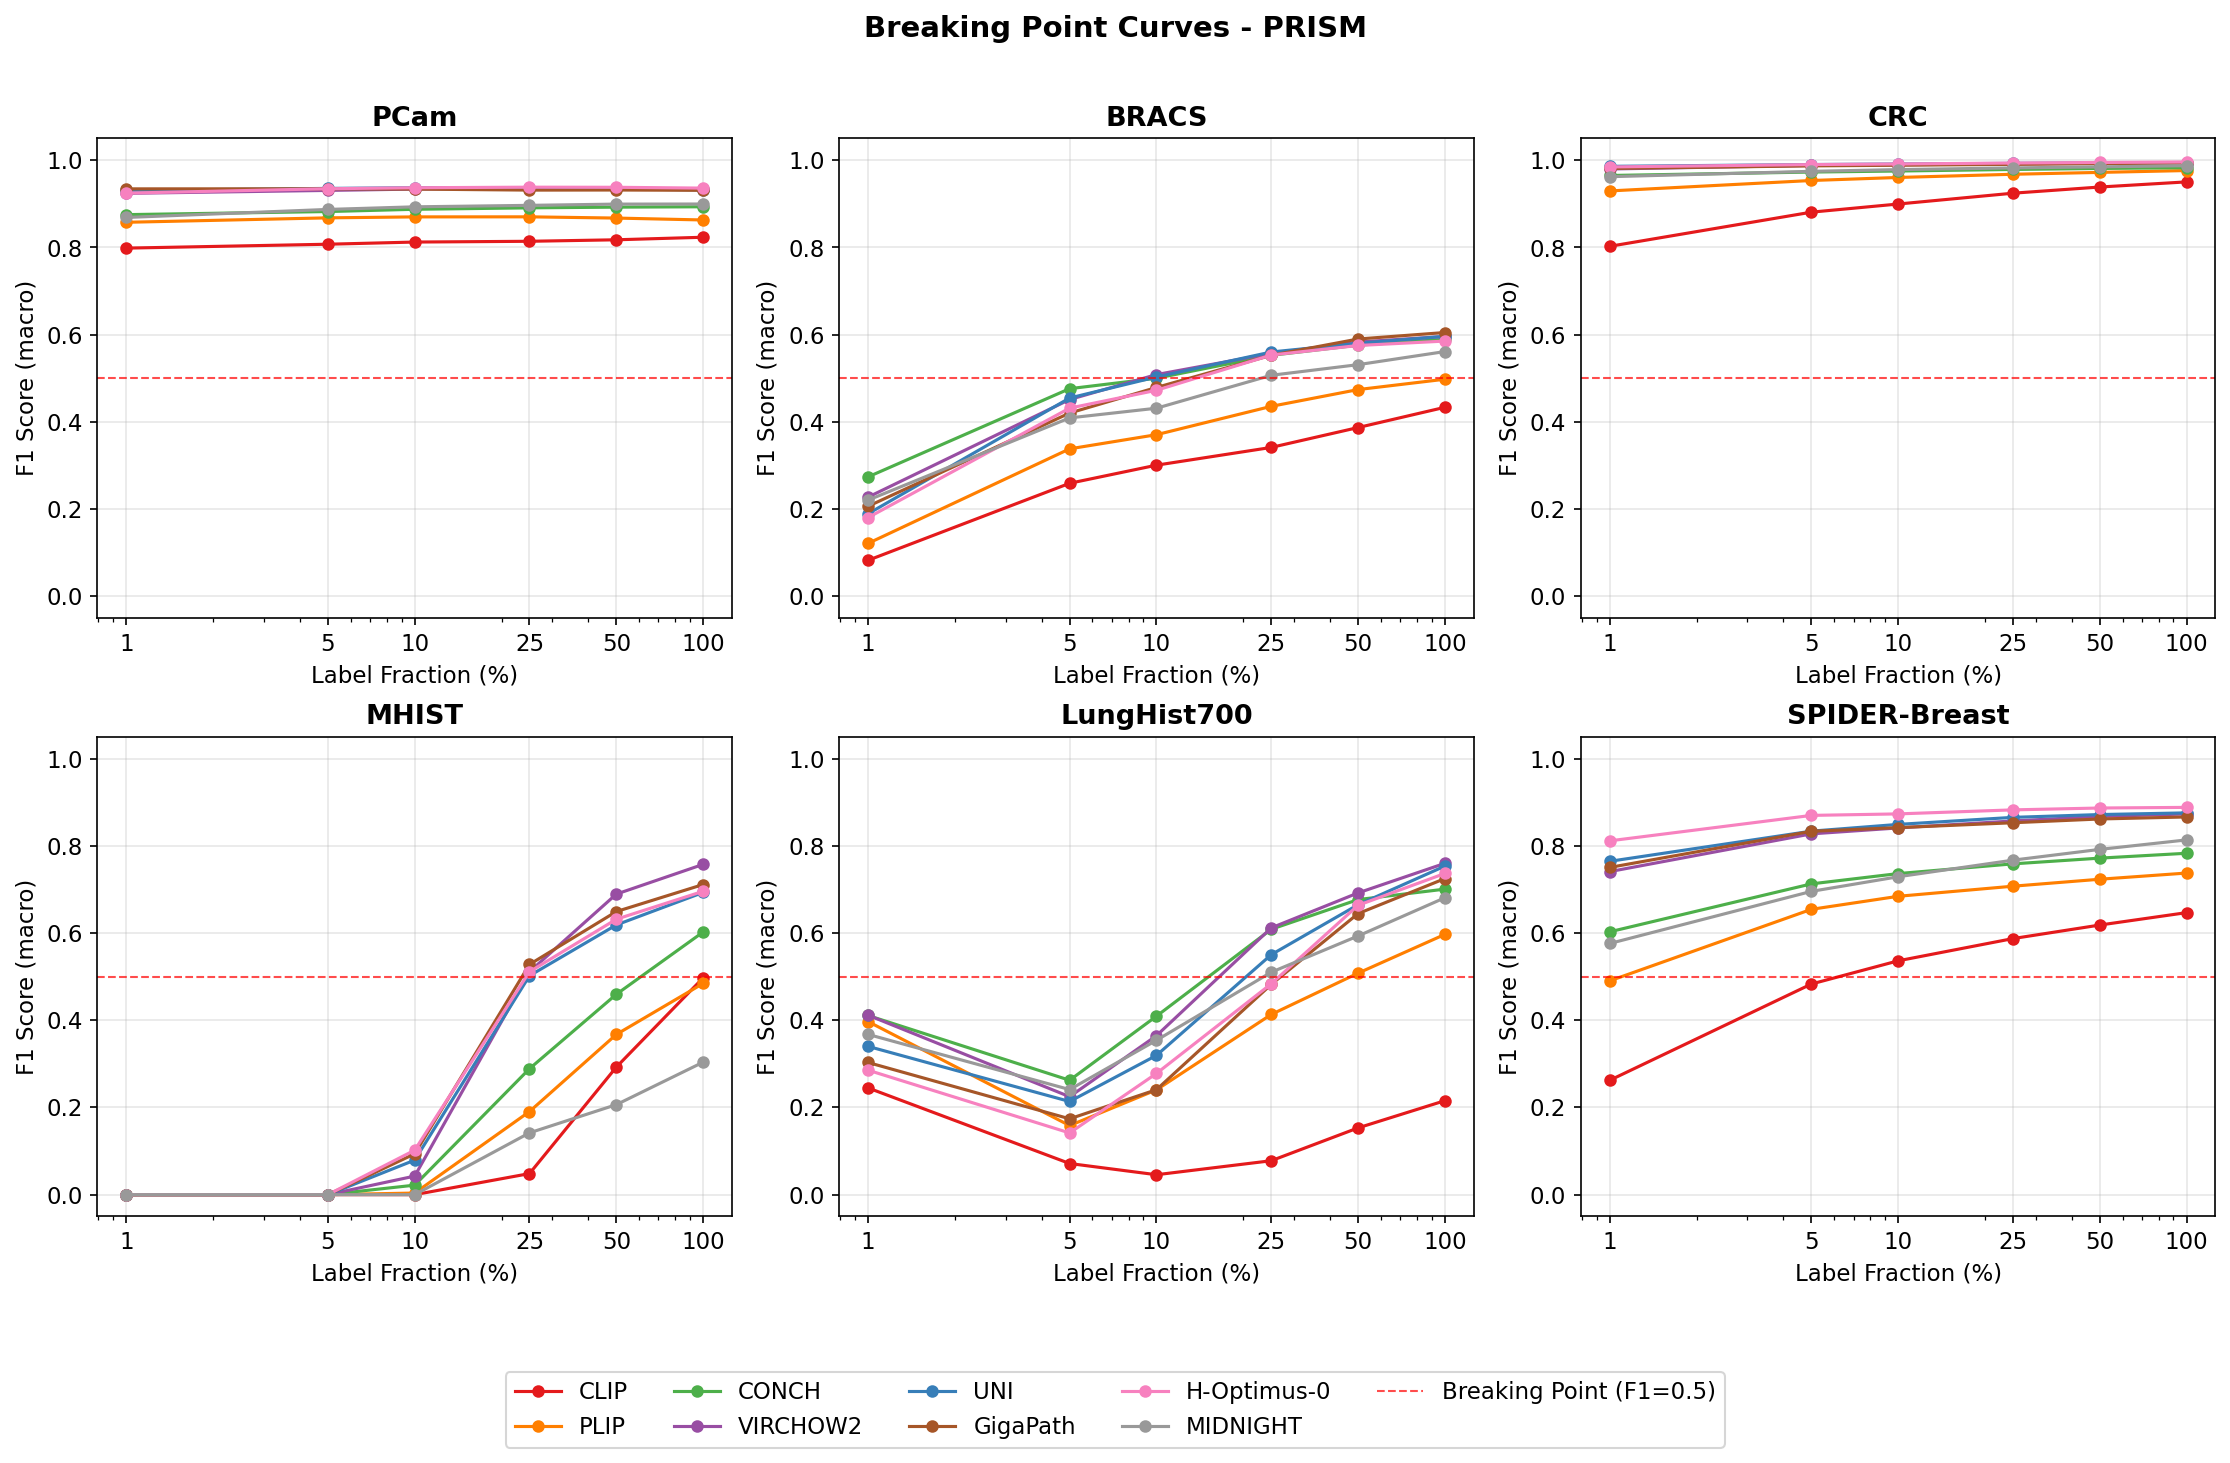

Saved: breaking_point_curves.pdf/png


In [20]:
# Breaking Point Curves
# Breaking Point = smallest fraction where F1 > threshold (0.5)

F1_THRESHOLD = 0.5

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_idx, ds in enumerate(DATASETS):
    ax = axes[ax_idx]
    fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

    for model in MODELS:
        f1_vals = []
        for frac in fractions:
            row = merged[(merged['model']==model) &
                        (merged['dataset']==ds) &
                        (merged['fraction']==frac)]
            f1_vals.append(row['f1_mean'].values[0] if len(row) > 0 else np.nan)

        ax.plot([f*100 for f in fractions], f1_vals,
                marker='o', markersize=5,
                color=MODEL_COLORS[model], label=model, linewidth=1.5)

    ax.axhline(y=F1_THRESHOLD, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Breaking Point (F1=0.5)')
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Label Fraction (%)')
    ax.set_ylabel('F1 Score (macro)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 25, 50, 100])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Breaking Point Curves - PRISM', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(f'{FIGURES_DIR}/breaking_point_curves.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/breaking_point_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: breaking_point_curves.pdf/png")

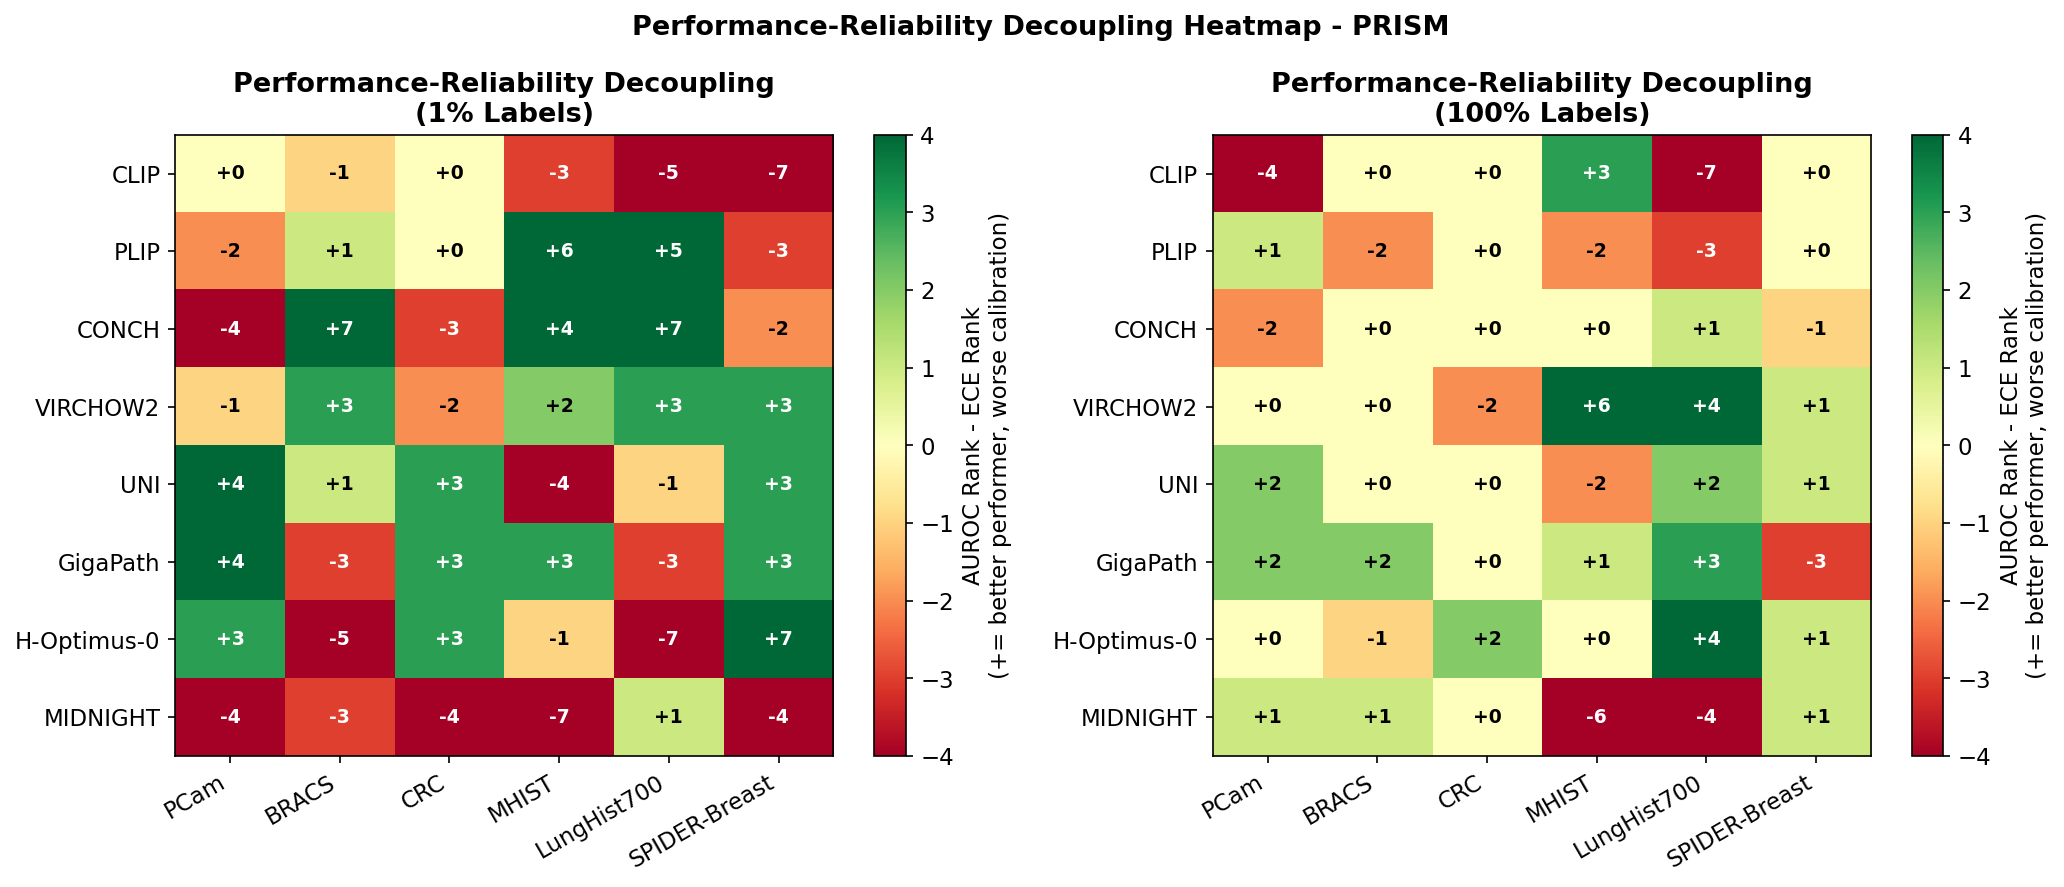

Saved: decoupling_heatmap.pdf/png


In [21]:
# Performance-Reliability Decoupling Heatmap
# Shows AUROC rank vs ECE rank - models that are top performers but poor calibrators

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for frac_idx, (frac, frac_label) in enumerate([(0.01, '1% Labels'), (1.00, '100% Labels')]):
    ax = axes[frac_idx]

    # Build matrix: rows=models, cols=datasets
    auroc_mat = np.zeros((len(MODELS), len(DATASETS)))
    ece_mat   = np.zeros((len(MODELS), len(DATASETS)))

    for i, model in enumerate(MODELS):
        for j, ds in enumerate(DATASETS):
            row = merged[(merged['model']==model) &
                        (merged['dataset']==ds) &
                        (merged['fraction']==frac)]
            if len(row) > 0:
                auroc_mat[i,j] = row['auroc_mean'].values[0]
                ece_mat[i,j]   = row['ece_mean'].values[0]

    # Decoupling = AUROC_rank - ECE_rank (higher = better performer but worse calibration)
    auroc_ranks = auroc_mat.argsort(axis=0).argsort(axis=0)  # 0=worst, 7=best
    ece_ranks   = ece_mat.argsort(axis=0)[::-1].argsort(axis=0)  # 0=worst (high ECE), 7=best (low ECE)
    decoupling  = auroc_ranks - ece_ranks

    im = ax.imshow(decoupling, cmap='RdYlGn', vmin=-4, vmax=4, aspect='auto')
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels(DATASETS, rotation=30, ha='right')
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS)
    ax.set_title(f'Performance-Reliability Decoupling\n({frac_label})', fontweight='bold')

    # Annotate
    for i in range(len(MODELS)):
        for j in range(len(DATASETS)):
            val = decoupling[i,j]
            ax.text(j, i, f'{val:+d}', ha='center', va='center',
                   fontsize=9, fontweight='bold',
                   color='white' if abs(val) > 2 else 'black')

    plt.colorbar(im, ax=ax, label='AUROC Rank - ECE Rank\n(+= better performer, worse calibration)')

plt.suptitle('Performance-Reliability Decoupling Heatmap - PRISM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/decoupling_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/decoupling_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: decoupling_heatmap.pdf/png")

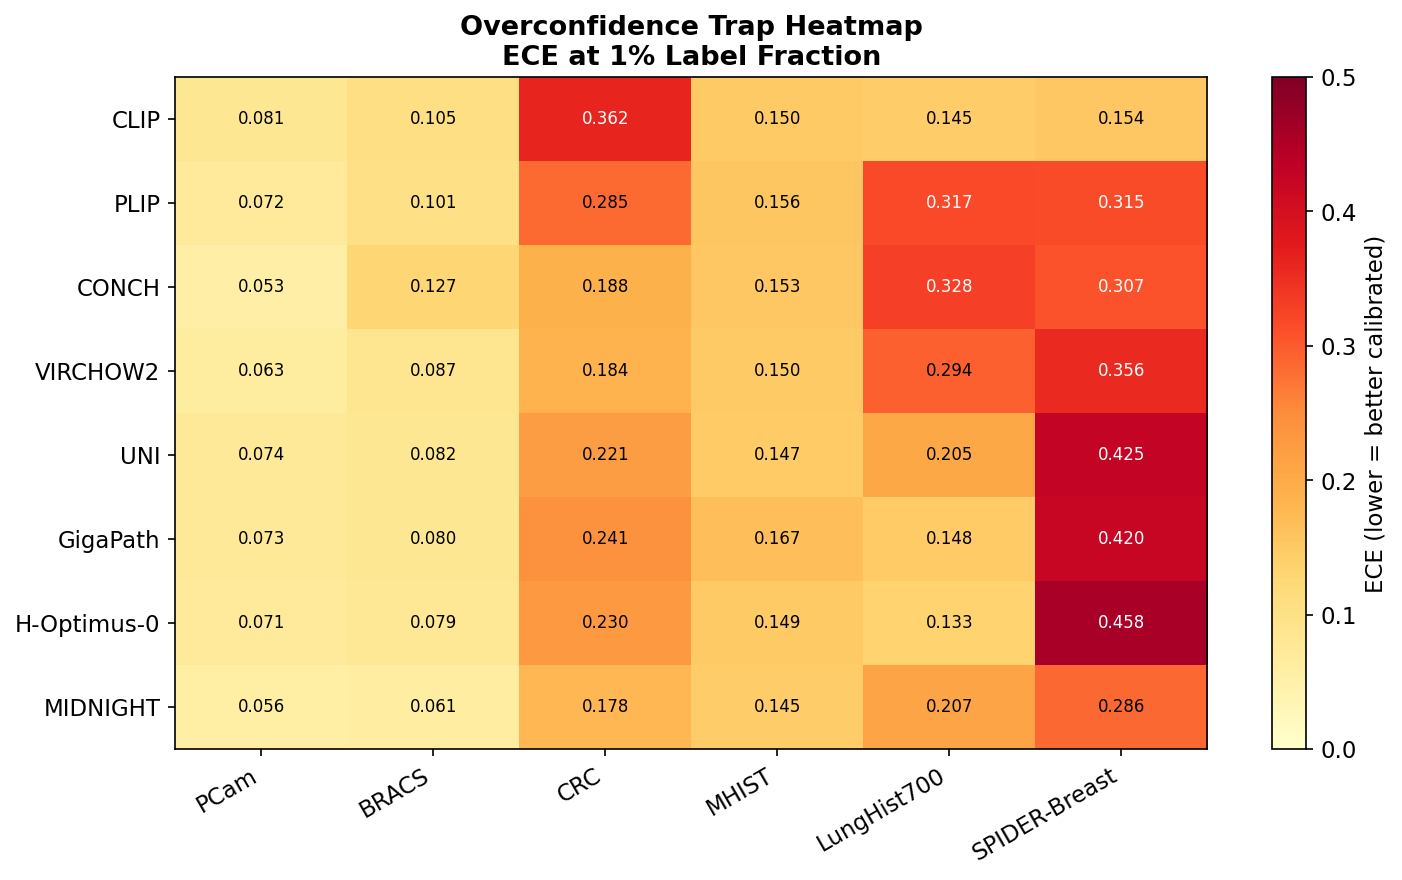

Saved: overconfidence_heatmap.pdf/png


In [22]:
# Overconfidence Trap Heatmap
# ECE at 1% for each model × dataset combination

ece_matrix = np.zeros((len(MODELS), len(DATASETS)))

for i, model in enumerate(MODELS):
    for j, ds in enumerate(DATASETS):
        row = merged[(merged['model']==model) &
                    (merged['dataset']==ds) &
                    (merged['fraction']==0.01)]
        if len(row) > 0:
            ece_matrix[i,j] = row['ece_mean'].values[0]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(ece_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)

ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels(DATASETS, rotation=30, ha='right')
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(MODELS)
ax.set_title('Overconfidence Trap Heatmap\nECE at 1% Label Fraction',
             fontweight='bold', fontsize=13)

for i in range(len(MODELS)):
    for j in range(len(DATASETS)):
        val = ece_matrix[i,j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
               fontsize=8, color='white' if val > 0.3 else 'black')

plt.colorbar(im, ax=ax, label='ECE (lower = better calibrated)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overconfidence_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/overconfidence_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: overconfidence_heatmap.pdf/png")

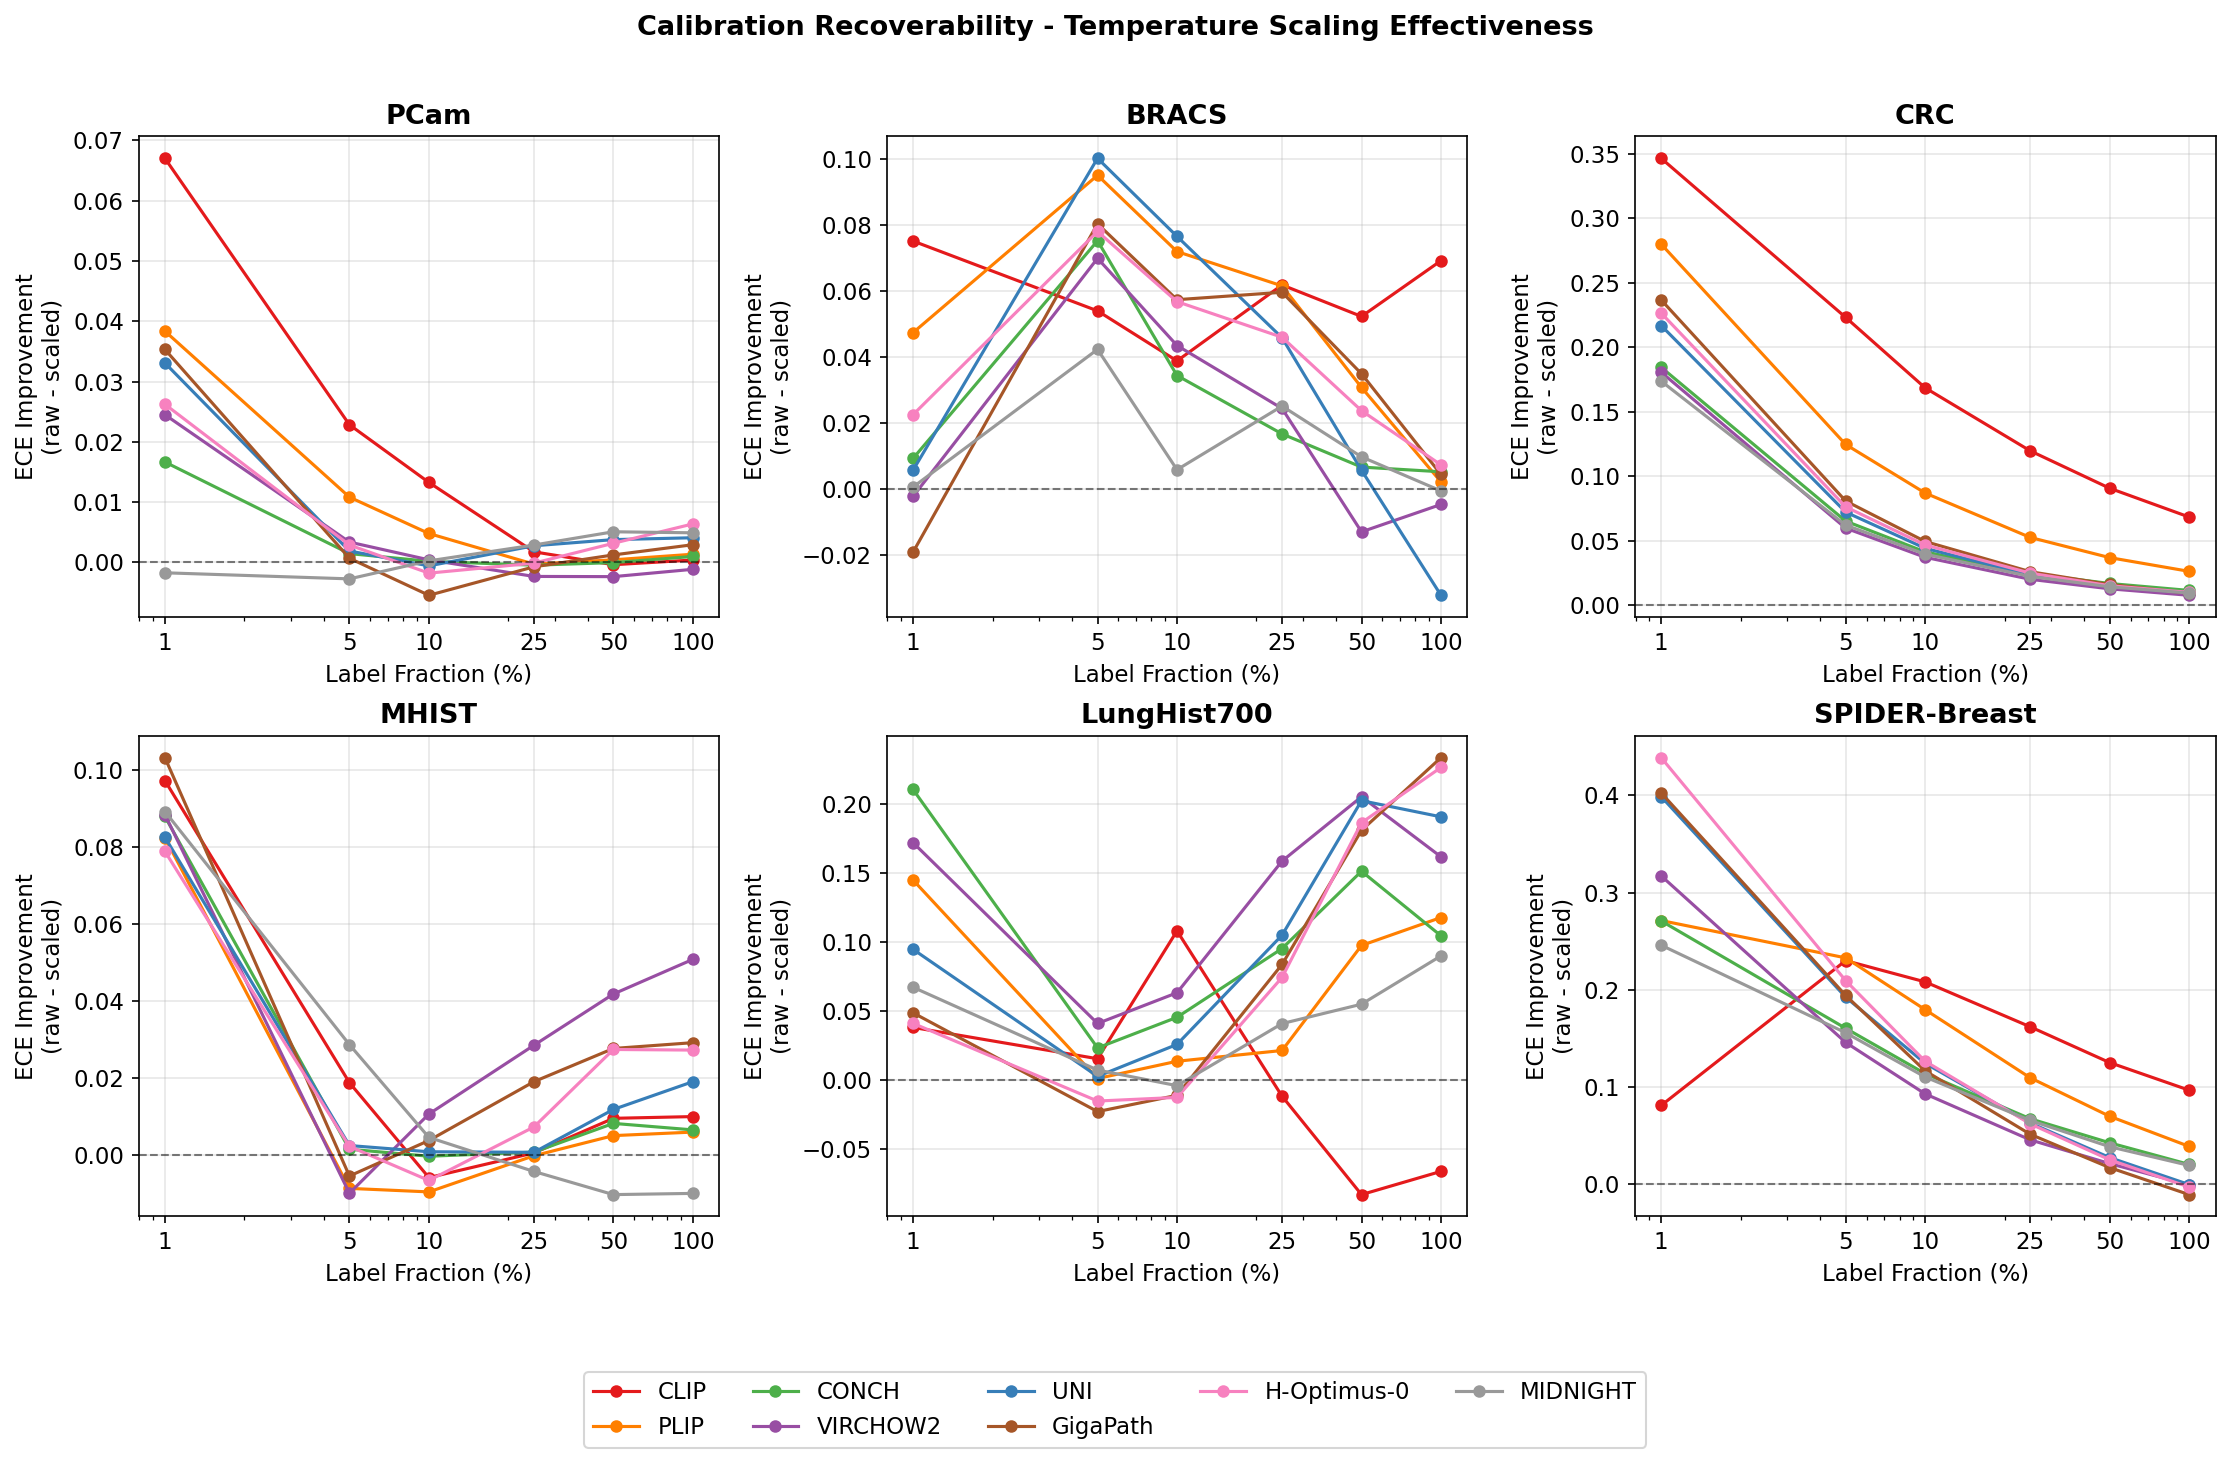

Saved: calibration_recoverability.pdf/png


In [23]:
# Calibration Recoverability
# How much temperature scaling helps at each fraction

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_idx, ds in enumerate(DATASETS):
    ax = axes[ax_idx]
    fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

    for model in MODELS:
        improvements = []
        for frac in fractions:
            row = ts_summary[(ts_summary['model']==model) &
                            (ts_summary['dataset']==ds) &
                            (ts_summary['fraction']==frac)]
            if len(row) > 0:
                improvements.append(row['ece_improvement'].values[0])
            else:
                improvements.append(np.nan)

        ax.plot([f*100 for f in fractions], improvements,
                marker='o', markersize=5,
                color=MODEL_COLORS[model], label=model, linewidth=1.5)

    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Label Fraction (%)')
    ax.set_ylabel('ECE Improvement\n(raw - scaled)')
    ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 25, 50, 100])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Calibration Recoverability - Temperature Scaling Effectiveness',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(f'{FIGURES_DIR}/calibration_recoverability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/calibration_recoverability.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: calibration_recoverability.pdf/png")

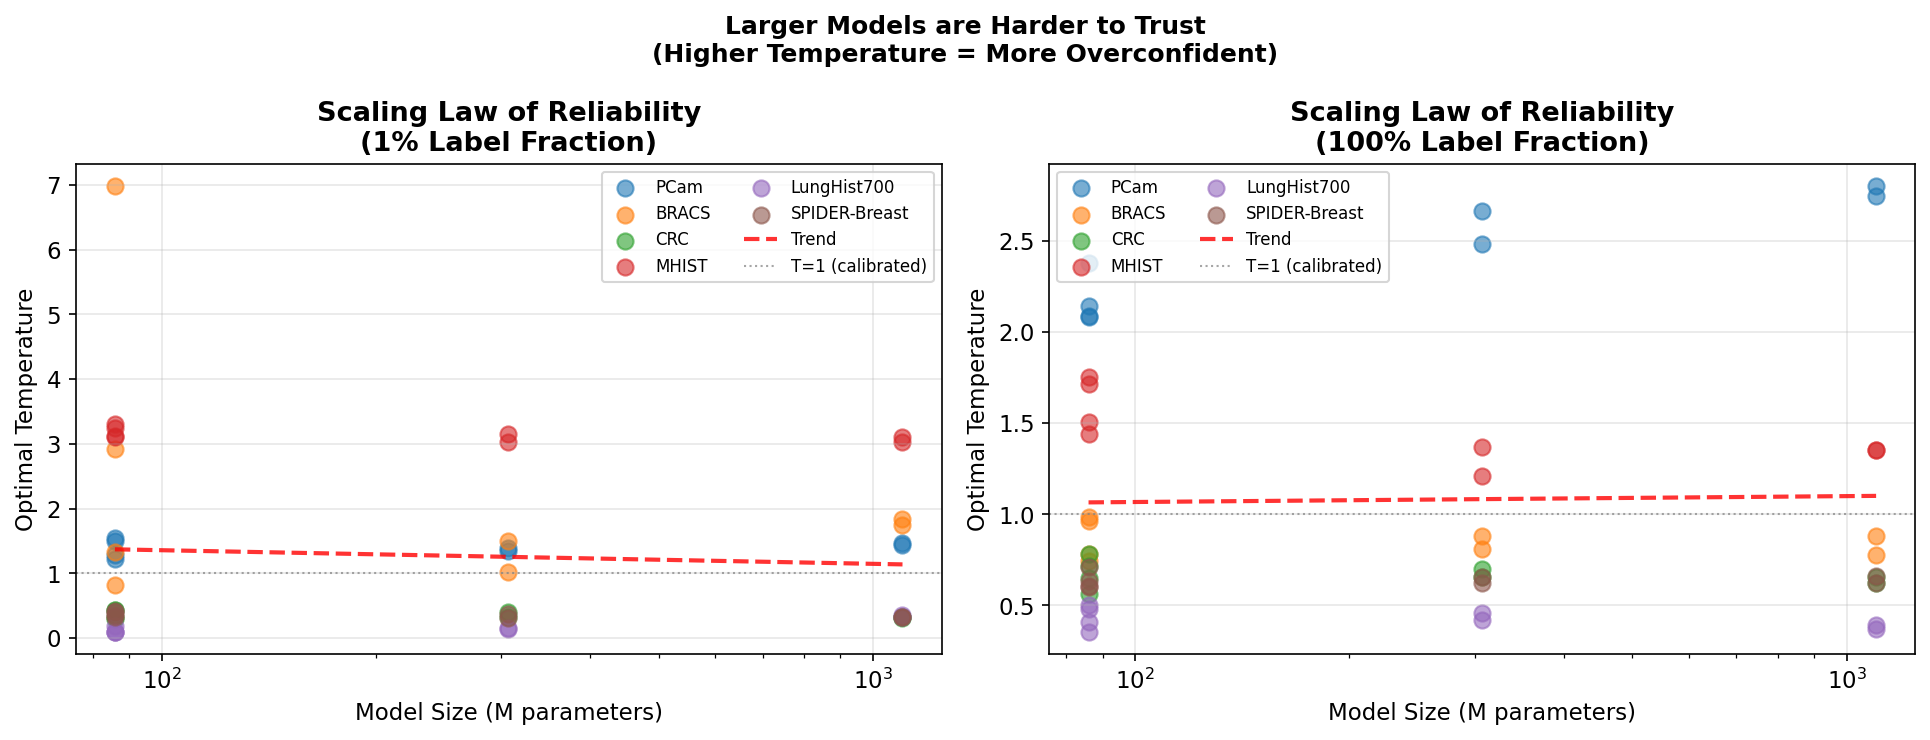

Saved: scaling_law_reliability.pdf/png


In [24]:
# Scaling Law of Reliability
# Larger models → higher temperature (more overconfident)

# Model sizes (approximate parameter counts in millions)
MODEL_SIZES = {
    'CLIP':        86,
    'PLIP':        86,
    'CONCH':       86,
    'MIDNIGHT':    86,
    'VIRCHOW2':    307,
    'UNI':         307,
    'GigaPath':    1100,
    'H-Optimus-0': 1100,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, frac in enumerate([0.01, 1.0]):
    ax = axes[ax_idx]

    for ds in DATASETS:
        temps = []
        sizes = []
        for model in MODELS:
            row = ts_summary[(ts_summary['model']==model) &
                            (ts_summary['dataset']==ds) &
                            (ts_summary['fraction']==frac)]
            if len(row) > 0:
                temps.append(row['temperature'].values[0])
                sizes.append(MODEL_SIZES[model])

        ax.scatter(sizes, temps, alpha=0.6, s=60, label=ds)

    # Trend line
    all_sizes, all_temps = [], []
    for model in MODELS:
        for ds in DATASETS:
            row = ts_summary[(ts_summary['model']==model) &
                            (ts_summary['dataset']==ds) &
                            (ts_summary['fraction']==frac)]
            if len(row) > 0:
                all_sizes.append(MODEL_SIZES[model])
                all_temps.append(row['temperature'].values[0])

    if len(all_sizes) > 1:
        z = np.polyfit(np.log(all_sizes), all_temps, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min(all_sizes), max(all_sizes), 100)
        ax.plot(x_line, p(np.log(x_line)), 'r--', linewidth=2, label='Trend', alpha=0.8)

    ax.set_xscale('log')
    ax.set_xlabel('Model Size (M parameters)')
    ax.set_ylabel('Optimal Temperature')
    ax.set_title(f'Scaling Law of Reliability\n({int(frac*100)}% Label Fraction)', fontweight='bold')
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, linewidth=1, label='T=1 (calibrated)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Larger Models are Harder to Trust\n(Higher Temperature = More Overconfident)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/scaling_law_reliability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/scaling_law_reliability.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: scaling_law_reliability.pdf/png")

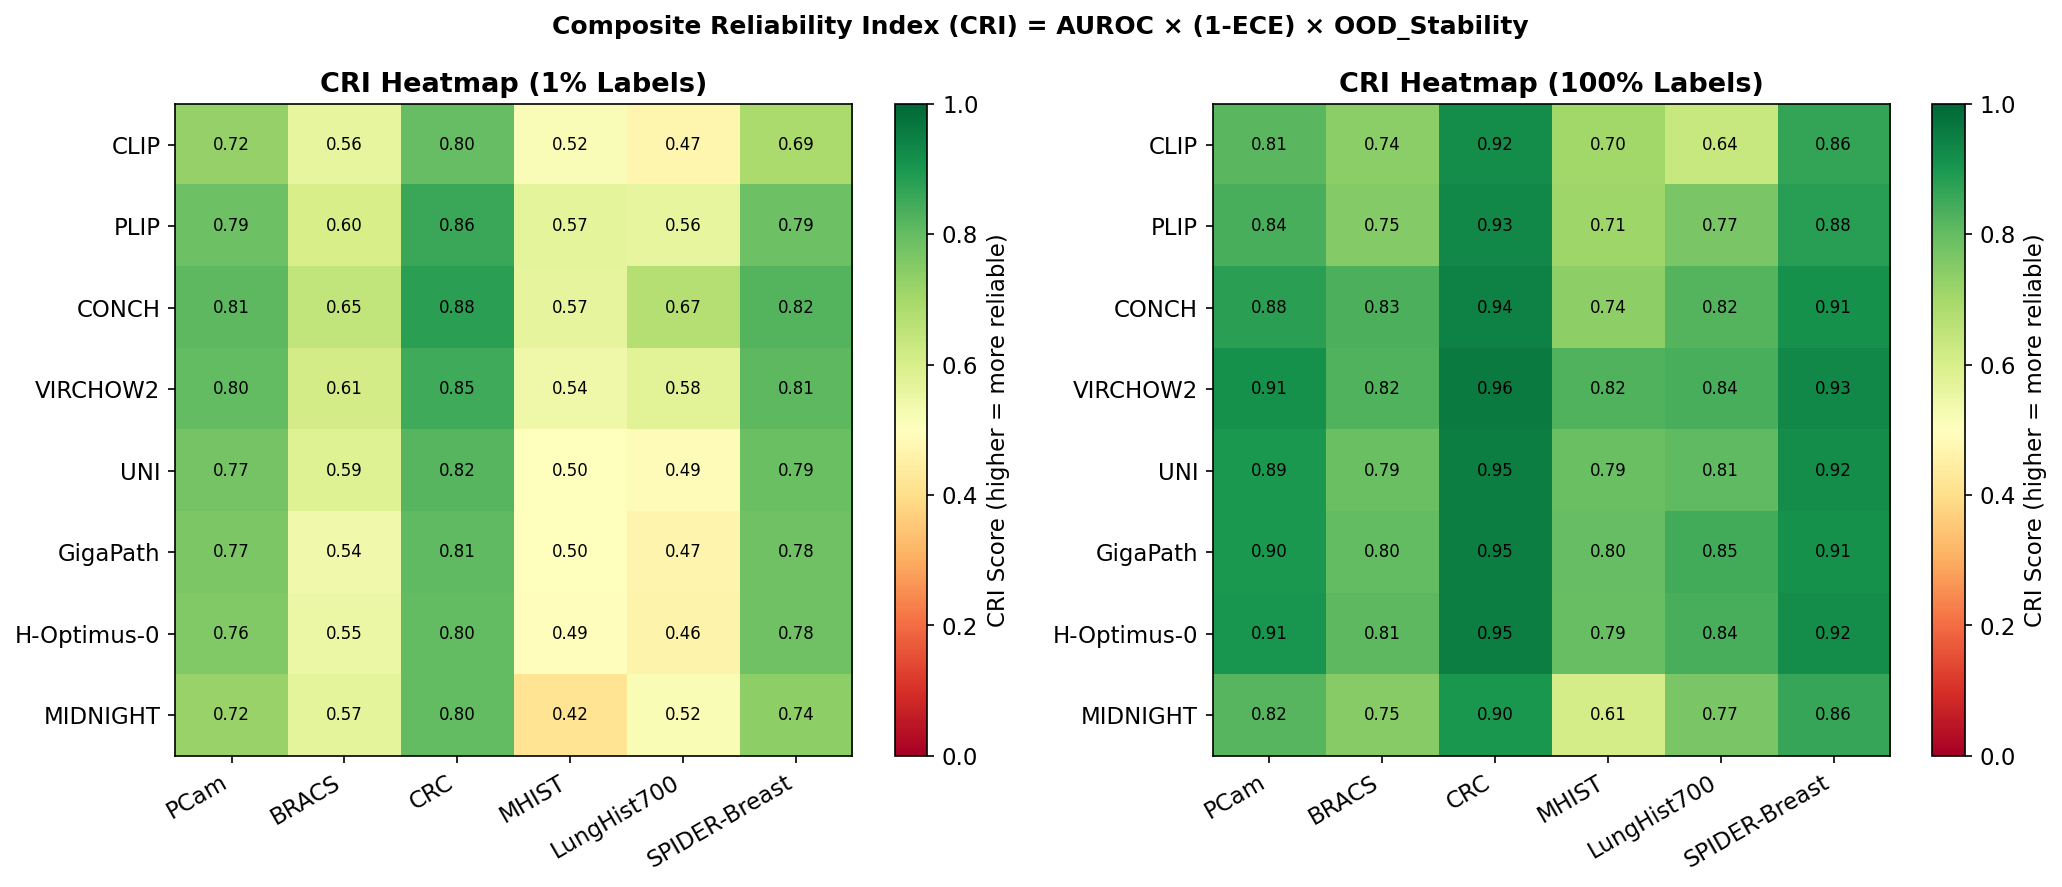

Saved: cri_heatmap.pdf/png


In [25]:
# CRI Heatmap at 1% and 100% label fractions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (frac, frac_label) in enumerate([(0.01, '1% Labels'), (1.00, '100% Labels')]):
    ax = axes[ax_idx]

    cri_mat = np.zeros((len(MODELS), len(DATASETS)))
    for i, model in enumerate(MODELS):
        for j, ds in enumerate(DATASETS):
            row = df_cri[(df_cri['model']==model) &
                        (df_cri['dataset']==ds) &
                        (df_cri['fraction']==frac)]
            if len(row) > 0:
                cri_mat[i,j] = row['cri'].values[0]

    im = ax.imshow(cri_mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels(DATASETS, rotation=30, ha='right')
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS)
    ax.set_title(f'CRI Heatmap ({frac_label})', fontweight='bold')

    for i in range(len(MODELS)):
        for j in range(len(DATASETS)):
            val = cri_mat[i,j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=8, color='white' if val < 0.3 else 'black')

    plt.colorbar(im, ax=ax, label='CRI Score (higher = more reliable)')

plt.suptitle('Composite Reliability Index (CRI) = AUROC × (1-ECE) × OOD_Stability',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cri_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/cri_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: cri_heatmap.pdf/png")

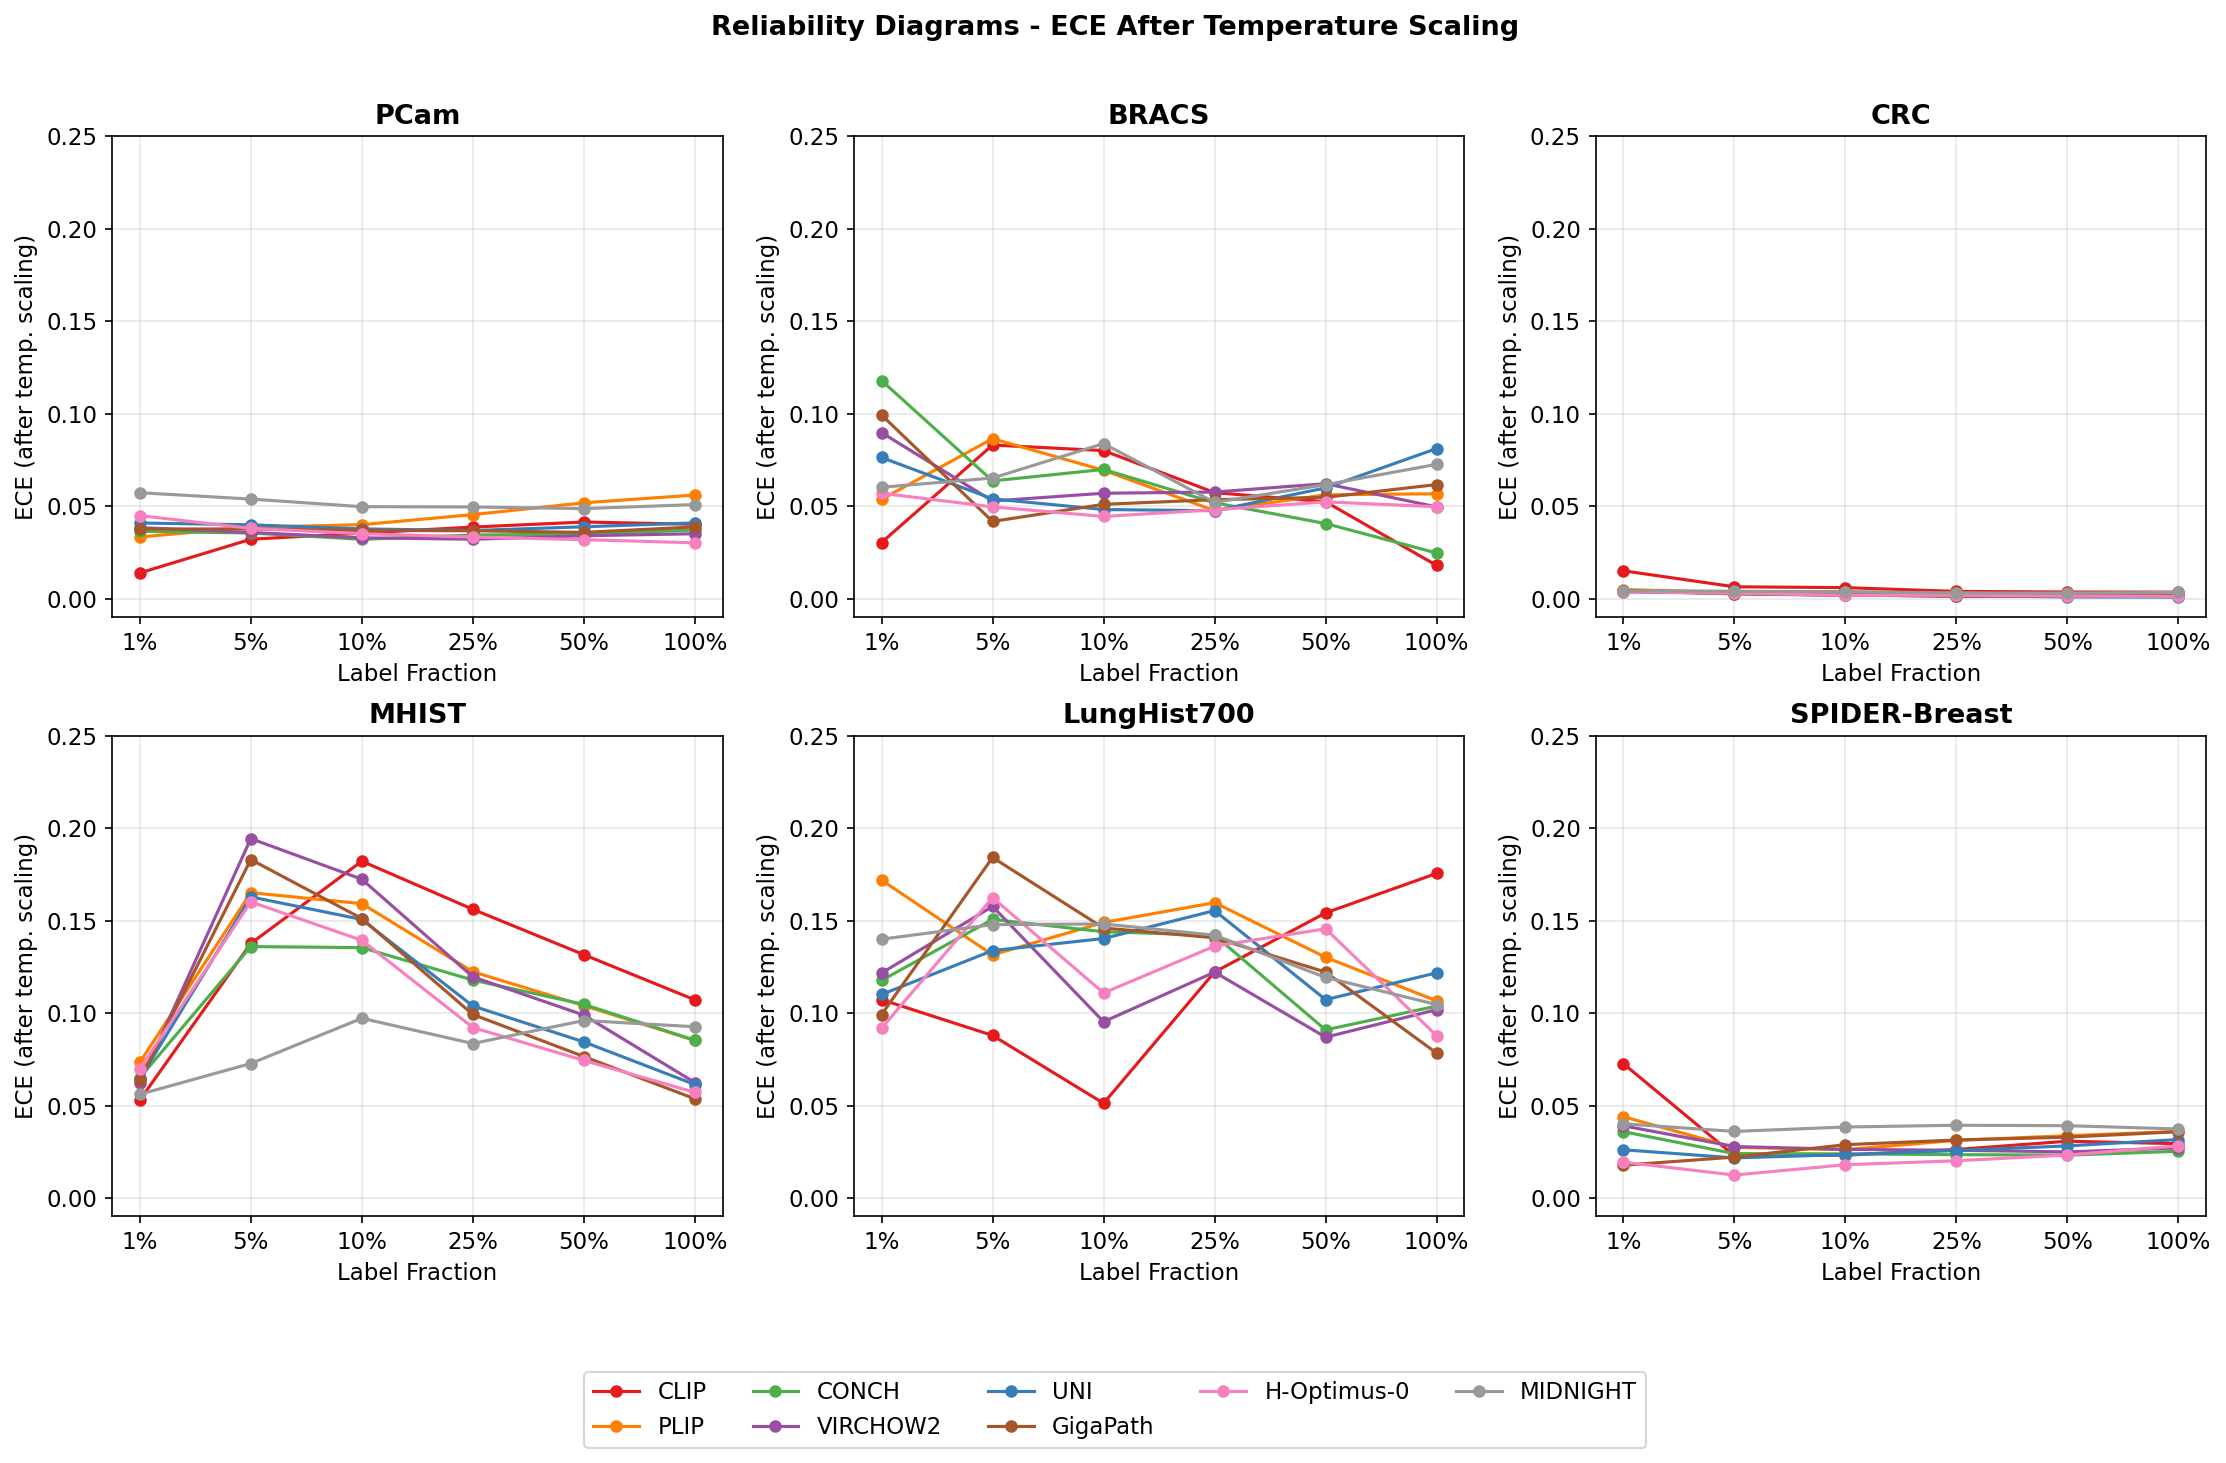

Saved: reliability_diagrams.pdf/png


In [26]:
# Reliability Diagrams (ECE curves across fractions)
# One plot per dataset, all models

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
frac_labels = ['1%', '5%', '10%', '25%', '50%', '100%']

for ax_idx, ds in enumerate(DATASETS):
    ax = axes[ax_idx]

    for model in MODELS:
        ece_vals = []
        for frac in fractions:
            row = merged[(merged['model']==model) &
                        (merged['dataset']==ds) &
                        (merged['fraction']==frac)]
            ece_vals.append(row['ece_scaled'].values[0] if len(row) > 0 else np.nan)

        ax.plot(frac_labels, ece_vals,
                marker='o', markersize=5,
                color=MODEL_COLORS[model], label=model, linewidth=1.5)

    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Label Fraction')
    ax.set_ylabel('ECE (after temp. scaling)')
    ax.set_ylim(-0.01, 0.25)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Reliability Diagrams - ECE After Temperature Scaling',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(f'{FIGURES_DIR}/reliability_diagrams.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{FIGURES_DIR}/reliability_diagrams.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reliability_diagrams.pdf/png")

In [27]:
# Final Summary Table - Paper Ready

# Mean CRI across all datasets per model and fraction
cri_summary = df_cri.groupby(['model','fraction'])['cri'].mean().reset_index()
cri_pivot = cri_summary.pivot(index='model', columns='fraction', values='cri')
cri_pivot.columns = [f'{int(c*100)}%' for c in cri_pivot.columns]
cri_pivot = cri_pivot.round(3)

print("=== Mean CRI Across All Datasets ===")
print(cri_pivot.to_string())

print("\n=== Breaking Points (fraction where F1 > 0.5) ===")
bp_rows = []
for model in MODELS:
    for ds in DATASETS:
        bp = 'Never'
        for frac in [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]:
            row = merged[(merged['model']==model) &
                        (merged['dataset']==ds) &
                        (merged['fraction']==frac)]
            if len(row) > 0 and row['f1_mean'].values[0] >= 0.5:
                bp = f'{int(frac*100)}%'
                break
        bp_rows.append({'model': model, 'dataset': ds, 'breaking_point': bp})

bp_df = pd.DataFrame(bp_rows)
bp_pivot = bp_df.pivot(index='model', columns='dataset', values='breaking_point')
print(bp_pivot.to_string())

# Save tables
cri_pivot.to_csv(f'{RESULTS_DIR}/cri_summary.csv')
bp_pivot.to_csv(f'{RESULTS_DIR}/breaking_points.csv')
print("\nSaved: cri_summary.csv, breaking_points.csv")

=== Mean CRI Across All Datasets ===
                1%     5%    10%    25%    50%   100%
model                                                
CLIP         0.626  0.702  0.722  0.751  0.763  0.779
CONCH        0.731  0.780  0.795  0.822  0.842  0.854
GigaPath     0.643  0.749  0.786  0.831  0.851  0.869
H-Optimus-0  0.641  0.735  0.781  0.827  0.846  0.869
MIDNIGHT     0.627  0.688  0.702  0.743  0.766  0.783
PLIP         0.695  0.741  0.754  0.778  0.795  0.813
UNI          0.660  0.760  0.793  0.825  0.850  0.859
VIRCHOW2     0.698  0.788  0.829  0.851  0.871  0.882

=== Breaking Points (fraction where F1 > 0.5) ===
dataset      BRACS CRC LungHist700  MHIST PCam SPIDER-Breast
model                                                       
CLIP         Never  1%       Never  Never   1%           10%
CONCH          10%  1%         25%   100%   1%            1%
GigaPath       25%  1%         50%    25%   1%            1%
H-Optimus-0    25%  1%         50%    25%   1%            1%
MIDNIG

In [28]:
# Bootstrap CI on CRI - Paper Quality Stats

print("=== 95% Bootstrap CI on CRI at 1% (all datasets) ===\n")

for model in MODELS:
    cri_vals = df_cri[(df_cri['model']==model) & (df_cri['fraction']==0.01)]['cri'].values
    if len(cri_vals) > 0:
        mean_cri = cri_vals.mean()
        # Bootstrap across datasets
        boots = [np.random.choice(cri_vals, size=len(cri_vals), replace=True).mean()
                 for _ in range(2000)]
        lo, hi = np.percentile(boots, [2.5, 97.5])
        print(f"  {model:15s}: {mean_cri:.3f} [{lo:.3f}, {hi:.3f}]")

print("\n=== 95% Bootstrap CI on CRI at 100% (all datasets) ===\n")
for model in MODELS:
    cri_vals = df_cri[(df_cri['model']==model) & (df_cri['fraction']==1.0)]['cri'].values
    if len(cri_vals) > 0:
        mean_cri = cri_vals.mean()
        boots = [np.random.choice(cri_vals, size=len(cri_vals), replace=True).mean()
                 for _ in range(2000)]
        lo, hi = np.percentile(boots, [2.5, 97.5])
        print(f"  {model:15s}: {mean_cri:.3f} [{lo:.3f}, {hi:.3f}]")

=== 95% Bootstrap CI on CRI at 1% (all datasets) ===

  CLIP           : 0.626 [0.537, 0.716]
  PLIP           : 0.695 [0.608, 0.793]
  CONCH          : 0.731 [0.644, 0.817]
  VIRCHOW2       : 0.698 [0.596, 0.794]
  UNI            : 0.660 [0.555, 0.762]
  GigaPath       : 0.643 [0.532, 0.748]
  H-Optimus-0    : 0.641 [0.533, 0.745]
  MIDNIGHT       : 0.627 [0.517, 0.730]

=== 95% Bootstrap CI on CRI at 100% (all datasets) ===

  CLIP           : 0.779 [0.700, 0.857]
  PLIP           : 0.813 [0.752, 0.877]
  CONCH          : 0.854 [0.798, 0.905]
  VIRCHOW2       : 0.882 [0.842, 0.926]
  UNI            : 0.859 [0.810, 0.912]
  GigaPath       : 0.869 [0.824, 0.915]
  H-Optimus-0    : 0.869 [0.825, 0.919]
  MIDNIGHT       : 0.783 [0.705, 0.853]
